In [ ]:
from IPython.display import Audio
from google.colab import drive
import torch
import librosa.display
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from collections import Counter
from imblearn.over_sampling import SMOTE
import torchaudio
import librosa
import os
import re

In [ ]:
# Google Drive'ı bağlama
drive.mount('/content/drive')

# Google Drive'daki klasör yolu
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"

Mounted at /content/drive


In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"
# Etiketleri saklayacak liste
labels = []

# Dizin içindeki dosyaları gez
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):  # Sadece wav dosyalarını al
        file_name = file_name.strip()  # Olası boşlukları temizle
        match = re.match(
                r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)\.wav$', file_name
            )

        if match:
            patient_id = match.group(1)
            diagnosis = match.group(2).strip()
            sound_type = match.group(3).strip()
            measurement_location = match.group(4).strip()
            age = int(match.group(5))
            gender = match.group(6)

            # Etiketler listesine ekle
            labels.append({
                "file_name": file_name,
                "patient_id": patient_id,
                "diagnosis": diagnosis,
                "sound_type": sound_type,
                "measurement_location": measurement_location,
                "age": age,
                "gender": gender
            })
        else:
            print(f"No match for file: {file_name}")  # Regex'e uymayan dosyaları yazdır
# Etiketlerin çıktısını gözlemle
for label in labels:
    print(label)

{'file_name': 'BP109_N,N,P L M,26,M.wav', 'patient_id': 'BP109', 'diagnosis': 'N', 'sound_type': 'N', 'measurement_location': 'P L M', 'age': 26, 'gender': 'M'}
{'file_name': 'BP107_Asthma,E W,P L U,59,F.wav', 'patient_id': 'BP107', 'diagnosis': 'Asthma', 'sound_type': 'E W', 'measurement_location': 'P L U', 'age': 59, 'gender': 'F'}
{'file_name': 'BP108_COPD,E W,P R L ,63,M.wav', 'patient_id': 'BP108', 'diagnosis': 'COPD', 'sound_type': 'E W', 'measurement_location': 'P R L', 'age': 63, 'gender': 'M'}
{'file_name': 'BP102_N,N,P L L,41,M.wav', 'patient_id': 'BP102', 'diagnosis': 'N', 'sound_type': 'N', 'measurement_location': 'P L L', 'age': 41, 'gender': 'M'}
{'file_name': 'BP101_Asthma,E W,P L M,12,F.wav', 'patient_id': 'BP101', 'diagnosis': 'Asthma', 'sound_type': 'E W', 'measurement_location': 'P L M', 'age': 12, 'gender': 'F'}
{'file_name': 'BP103_N,N,P R U,81,F.wav', 'patient_id': 'BP103', 'diagnosis': 'N', 'sound_type': 'N', 'measurement_location': 'P R U', 'age': 81, 'gender': 

In [ ]:
len(labels)

324

In [ ]:
# Diagnosis etiketlerini alma ve ön işleme
try:
    diagnoses = [entry['diagnosis'].lower() for entry in labels]  # Tüm diagnosis etiketlerini al

    # Örnek: Benzersiz etiketleri listeleme
    unique_labels = set(diagnoses)
    print(f"Benzersiz etiketler: {unique_labels}")

    # Eğer belirli bir ön işleme yapacaksanız, buraya ekleyin
    # Örneğin: Etiketlerin sayısını hesaplama
    label_counts = {label: diagnoses.count(label) for label in unique_labels}
    print("Etiketlerin dağılımı:")
    for label, count in label_counts.items():
        print(f"{label}:{count}")

except KeyError as e:
    print(f"Hata: Bir kayıt 'diagnosis' anahtarını içermiyor: {e}")
except Exception as e:
    print(f"Beklenmeyen bir hata oluştu: {e}")

Benzersiz etiketler: {'copd', 'asthma', 'pneumonia', 'heart failure', 'n', 'plueral effusion', 'bron', 'lung fibrosis'}
Etiketlerin dağılımı:
copd:27
asthma:96
pneumonia:15
heart failure:54
n:105
plueral effusion:6
bron:9
lung fibrosis:12


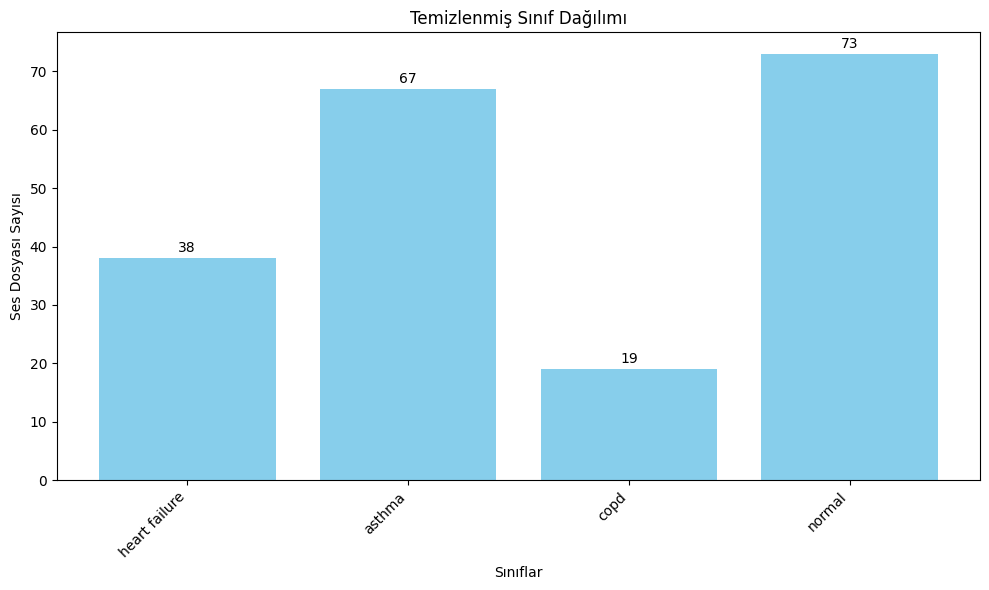

In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean"

# Etiketleri normalize etmek için haritalama sözlüğü
label_map = {
    'asthma and lung fibrosis': 'asthma',
    'heart failure + copd': 'heart failure',
    'heart failure + lung fibrosis': 'heart failure',
    'asthma': 'asthma',
    'bron': 'bronchiectasis',
    'bronchiectasis': 'bronchiectasis',
    'copd': 'copd',
    'heart failure': 'heart failure',
    'lung fibrosis': 'lung fibrosis',
    'pleural effusion': 'pleural effusion',
    'plueral effusion': 'pleural effusion',
    'pneumonia': 'pneumonia',
    'n': 'normal',
    'normal': 'normal',
    'healthy': 'normal'
}

# Orijinal etiket listesini normalize et
cleaned_labels = []
for lbl in diagnoses:
    lbl_clean = lbl.lower().strip()
    if lbl_clean in label_map:
        cleaned_labels.append(label_map[lbl_clean])
    else:
        print(f"⚠️ Bilinmeyen etiket: '{lbl_clean}'")

# Etiket sayacı
u_class_counts = {}

# Ses dosyalarını dolaş ve etiketle
for file_name in os.listdir(directory):
    if file_name.endswith(".wav"):
        try:
            file_label_raw = file_name.split('_')[1].split(',')[0].strip().lower()
            mapped_label = label_map.get(file_label_raw)

            if mapped_label:
                u_class_counts[mapped_label] = u_class_counts.get(mapped_label, 0) + 1
            else:
                print(f"⚠️ Dosyada eşleşmeyen etiket: '{file_label_raw}' - {file_name}")
        except IndexError:
            print(f"⚠️ Hatalı dosya adı formatı: {file_name}")

# Grafikle göster
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)

plt.title('Temizlenmiş Sınıf Dağılımı')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Verilerinin bulunduğu klasörü buraya yaz:
data_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"

# Klasördeki tüm dosyaları döner
for filename in os.listdir(data_dir):
    if filename.endswith(".wav") and "_aug" in filename:
        file_path = os.path.join(data_dir, filename)
        try:
            os.remove(file_path)
            print(f"Silindi: {filename}")
        except Exception as e:
            print(f"Hata oluştu: {filename} -> {e}")


Silindi: DP14_Heart Failure,C,A R M,54,M_aug0.wav
Silindi: BP40_heart failure,Crep,A R M,26,M_aug1.wav
Silindi: BP67_heart failure,Crep,P R L ,24,F_aug2.wav
Silindi: BP39_heart failure,Crep,P R L ,67,M_aug3.wav
Silindi: DP45_heart failure,Crep,P R L ,30,M_aug4.wav
Silindi: EP90_heart failure,Crep,P L M,74,F_aug5.wav
Silindi: EP67_heart failure,Crep,P R L ,24,F_aug6.wav
Silindi: DP67_heart failure,Crep,P R L ,24,F_aug7.wav
Silindi: EP34_heart failure,Crep,P R M,78,F_aug8.wav
Silindi: BP29_heart failure,Crep,P L L,57,M_aug9.wav
Silindi: BP24_heart failure,Crep,P R L ,76,F_aug10.wav
Silindi: DP34_heart failure,Crep,P R M,78,F_aug11.wav
Silindi: DP39_heart failure,Crep,P R L ,67,M_aug12.wav
Silindi: DP66_heart failure,Crep,P R L ,43,M_aug13.wav
Silindi: BP13_Heart Failure,C,P L L,55,M_aug14.wav
Silindi: EP14_Heart Failure,C,A R M,54,M_aug15.wav
Silindi: BP66_heart failure,Crep,P R L ,43,M_aug16.wav
Silindi: EP60_heart failure,Crep,P L L,83,F_aug17.wav
Silindi: EP59_heart failure,Crep,P R L

In [ ]:
import os
import shutil

# Orijinal + augment dosyalarının olduğu klasör
src_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"

# Yeni, sadece orijinal dosyaların kopyalanacağı klasör
dst_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean"

os.makedirs(dst_dir, exist_ok=True)

for filename in os.listdir(src_dir):
    if not filename.endswith(".wav"):
        continue
    # "_aug" içermeyen dosyalar orijinal sayılır
    if "_aug" not in filename:
        src_path = os.path.join(src_dir, filename)
        dst_path = os.path.join(dst_dir, filename)
        try:
            shutil.copy2(src_path, dst_path)
            print(f"Kopyalandı: {filename}")
        except Exception as e:
            print(f"Hata oluştu {filename}: {e}")

print("✅ train4_clean klasörü oluşturuldu, yalnızca orijinal dosyalar içeriyor.")


Kopyalandı: DP14_Heart Failure,C,A R M,54,M.wav
Kopyalandı: EP35_Asthma,E W,A R L,38,M.wav
Kopyalandı: DP101_Asthma,E W,P L M,12,F.wav
Kopyalandı: BP67_heart failure,Crep,P R L ,24,F.wav
Kopyalandı: EP62_COPD,E W,P L M,53,M.wav
Kopyalandı: DP81_N,N,P L U,33,M.wav
Kopyalandı: BP31_N,N,P L M,27,F.wav
Kopyalandı: BP25_copd,E W,P L L,76,M.wav
Kopyalandı: BP40_heart failure,Crep,A R M,26,M.wav
Kopyalandı: DP32_N,N,A R L,30,M.wav
Kopyalandı: BP51_N,N,P L M,30,M.wav
Kopyalandı: EP110_COPD,E W,P L L,62,M.wav
Kopyalandı: BP49_N,N,P R M,21,M.wav
Kopyalandı: BP39_heart failure,Crep,P R L ,67,M.wav
Kopyalandı: EP107_Asthma,E W,P L U,59,F.wav
Kopyalandı: EP3_Asthma,I E W,P L L R,50,F.wav
Kopyalandı: DP45_heart failure,Crep,P R L ,30,M.wav
Kopyalandı: EP32_N,N,A R L,30,M.wav
Kopyalandı: EP87_N,N,P R M,72,M.wav
Kopyalandı: DP12_Asthma,E W,P L L,50,F.wav
Kopyalandı: EP100_N,N,P R M,70,F.wav
Kopyalandı: EP90_heart failure,Crep,P L M,74,F.wav
Kopyalandı: EP86_N,N,P R U,68,F.wav
Kopyalandı: DP67_heart fa

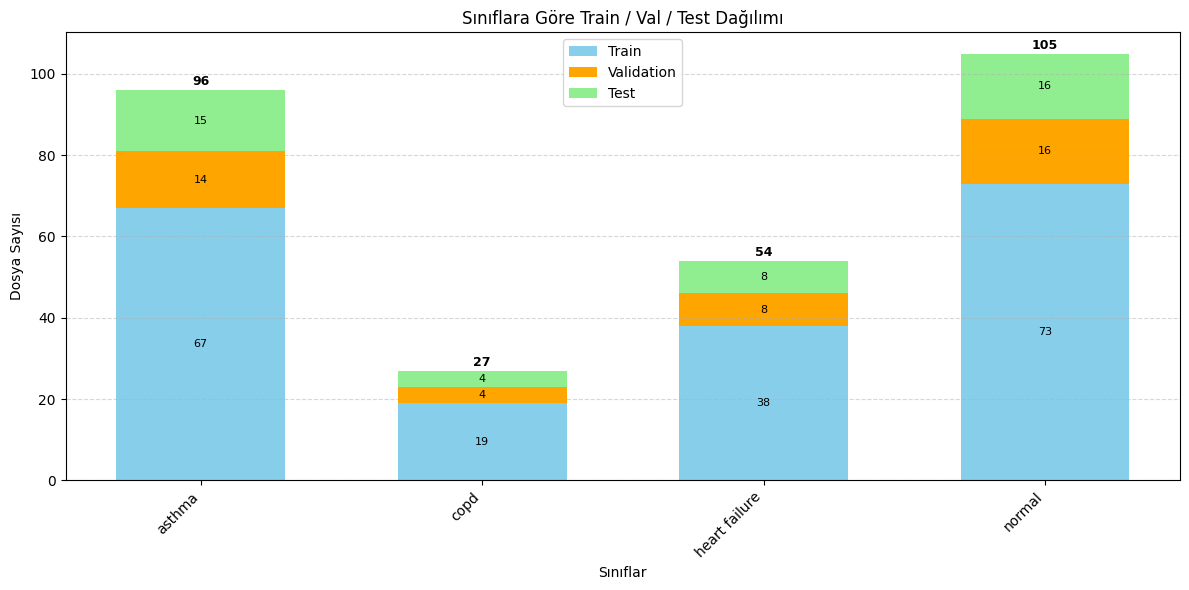

In [ ]:
def extract_label_from_filename(filename):
    match = re.match(r'^([BED]P\d+)_([^,]+),([^,]+),([^,]+),(\d+),?(M|F)\.wav$', filename)
    if match:
        diagnosis = match.group(2).strip().lower()
        if 'asthma' in diagnosis:
            return 'asthma'
        elif 'bron' in diagnosis:
            return 'bron'
        elif 'copd' in diagnosis:
            return 'copd'
        elif 'heart failure' in diagnosis:
            return 'heart failure'
        elif 'lung fibrosis' in diagnosis:
            return 'lung fibrosis'
        elif 'pleural effusion' in diagnosis or 'plueral effusion' in diagnosis:
            return 'pleural effusion'
        elif 'pneumonia' in diagnosis:
            return 'pneumonia'
        elif diagnosis == 'n':
            return 'normal'
    return None

def count_labels_from_directory(directory):
    label_counter = Counter()
    for filename in os.listdir(directory):
        if filename.endswith('.wav'):
            label = extract_label_from_filename(filename)
            if label:
                label_counter[label] += 1
    return label_counter

# Tüm klasörlerden sayımları al
train_counts = count_labels_from_directory("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean")
val_counts = count_labels_from_directory("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4")
test_counts = count_labels_from_directory("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4")

# Sınıf etiketlerinin birleşimini al
all_labels = sorted(set(train_counts.keys()) | set(val_counts.keys()) | set(test_counts.keys()))

# Her bir sınıf için dağılımları çıkar
train_vals = [train_counts[label] for label in all_labels]
val_vals = [val_counts[label] for label in all_labels]
test_vals = [test_counts[label] for label in all_labels]

# Grafik çizimi
x = np.arange(len(all_labels))
width = 0.6

plt.figure(figsize=(12, 6))

# Her aşamanın alt sınırlarını tut
train_bottoms = np.zeros(len(x))
val_bottoms = train_vals
test_bottoms = np.array(train_vals) + np.array(val_vals)

# Bar çizimleri
train_bars = plt.bar(x, train_vals, width, label='Train', color='skyblue')
val_bars = plt.bar(x, val_vals, width, bottom=train_vals, label='Validation', color='orange')
test_bars = plt.bar(x, test_vals, width, bottom=test_bottoms, label='Test', color='lightgreen')

# Her barın üstüne kendi sayısını yaz
for i in range(len(x)):
    if train_vals[i] > 0:
        plt.text(x[i], train_vals[i] / 2, str(train_vals[i]), ha='center', va='center', fontsize=8, color='black')
    if val_vals[i] > 0:
        plt.text(x[i], train_vals[i] + val_vals[i] / 2, str(val_vals[i]), ha='center', va='center', fontsize=8, color='black')
    if test_vals[i] > 0:
        plt.text(x[i], train_vals[i] + val_vals[i] + test_vals[i] / 2, str(test_vals[i]), ha='center', va='center', fontsize=8, color='black')

    # Toplamı en üste yaz
    total = train_vals[i] + val_vals[i] + test_vals[i]
    plt.text(x[i], total + 0.5, str(total), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.xticks(x, all_labels, rotation=45, ha='right')
plt.xlabel('Sınıflar')
plt.ylabel('Dosya Sayısı')
plt.title('Sınıflara Göre Train / Val / Test Dağılımı')
plt.legend()
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()



In [ ]:
directory = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/Audio Files"

def get_audio_duration_librosa(file_path):
    y, sr = librosa.load(file_path, sr=None)  # sr=None orijinal örnekleme hızını korur
    duration = librosa.get_duration(y=y, sr=sr)
    return duration  # saniye cinsinden

for filename in os.listdir(directory):
    if filename.endswith(".wav"):
        path = os.path.join(directory, filename)
        duration = get_audio_duration_librosa(path)  # veya get_audio_duration_librosa(path)
        print(f"{filename}: {duration:.2f} saniye")


BP109_N,N,P L M,26,M.wav: 13.23 saniye
BP107_Asthma,E W,P L U,59,F.wav: 12.66 saniye
BP108_COPD,E W,P R L ,63,M.wav: 22.83 saniye
BP102_N,N,P L L,41,M.wav: 19.06 saniye
BP101_Asthma,E W,P L M,12,F.wav: 13.55 saniye
BP103_N,N,P R U,81,F.wav: 12.85 saniye
BP106_Asthma,E W,P L U,45,F.wav: 19.82 saniye
BP104_Asthma,E W,P L U,45,F.wav: 11.76 saniye
BP100_N,N,P R M,70,F.wav: 13.55 saniye
BP105_Lung Fibrosis,Crep,A U R,44,M.wav: 25.26 saniye
DP23_Lung Fibrosis,Crep,P R L ,50,M.wav: 11.38 saniye
BP28_BRON,Crep,P L U,68,F.wav: 15.86 saniye
BP93_N,N,P R M,75,M.wav: 9.84 saniye
BP27_asthma,E W,P R M,53,F.wav: 13.94 saniye
BP89_N,N,P L M,70,M.wav: 22.06 saniye
DP22_BRON,Crep,P R U,24,M.wav: 5.00 saniye
BP71_N,N,P R U,36,M.wav: 14.38 saniye
BP33_Asthma,E W,P R M,43,F.wav: 17.57 saniye
BP95_N,N,P L M,18,M.wav: 13.55 saniye
BP32_N,N,A R L,30,M.wav: 18.35 saniye
BP42_heart failure,Crep,P L L,56,M.wav: 12.66 saniye
BP13_Heart Failure,C,P L L,55,M.wav: 14.58 saniye
BP45_heart failure,Crep,P R L ,30,M.wa

In [ ]:
durations = []
for filename in os.listdir(directory):
    if filename.endswith(".wav"):
        path = os.path.join(directory, filename)
        duration = get_audio_duration_librosa(path)
        durations.append(duration)
print(f"Toplam {len(durations)} dosya var.")
print(f"Minimum süre: {min(durations):.2f} saniye")
print(f"Maksimum süre: {max(durations):.2f} saniye")
print(f"Ortalama süre: {sum(durations)/len(durations):.2f} saniye")

Toplam 324 dosya var.
Minimum süre: 5.00 saniye
Maksimum süre: 30.00 saniye
Ortalama süre: 17.18 saniye


In [ ]:
def extract_label_from_filename(filename):
    # .wav uzantısını kontrol et
    if not filename.endswith('.wav'):
        return None

    # Dosya adını ayır
    basename = os.path.splitext(filename)[0]
    parts = basename.split("_")
    if len(parts) < 2:
        print(f"Beklenmeyen format: {filename}")
        return None

    diagnosis = parts[1].strip().lower()

    # Bazı dosyalarda tanı 'n,n,xxx' gibi olabilir
    if diagnosis.startswith('n,n'):
        return 'normal'

    # Hastalık etiketini belirle
    if 'asthma' in diagnosis:
        return 'asthma'
    elif 'copd' in diagnosis:
        return 'copd'
    elif 'heart failure' in diagnosis or 'heart_failure' in diagnosis:
        return 'heart failure'
    elif diagnosis == 'n':
        return 'normal'
    else:
        print(f"Eşleşmeyen tanı: {diagnosis} | Dosya: {filename}")
        return None


In [ ]:
def extract_mel_spectrogram(file_path, max_len=3000, sr=22050, n_mels=64, n_fft=1024, hop_length=512):
    try:
        # Ses dosyasını oku
        y, sr = librosa.load(file_path, sr=sr)

        # Sessizlikten oluşan dosyalarda hata almamak için kontrol et
        if y.size == 0:
            print(f"Boş ses dosyası: {file_path}")
            return None

        # Mel spectrogram çıkar
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                                   n_fft=n_fft, hop_length=hop_length)

        # dB cinsine dönüştür (log-scale)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # Normalize et (0-1 arası)
        mel_spec_db -= mel_spec_db.min()
        if mel_spec_db.max() != 0:
            mel_spec_db /= mel_spec_db.max()
        else:
            print(f"Normalize edilemeyen spectrogram (sıfır enerji): {file_path}")
            return None

        # Padding veya kırpma
        if mel_spec_db.shape[1] < max_len:
            pad_width = max_len - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :max_len]

        return mel_spec_db

    except Exception as e:
        print(f"Hata oluştu ({file_path}): {e}")
        return None


In [ ]:
def sliding_window(mel_spec, max_len=1500, stride=500):
    windows = []
    total_len = mel_spec.shape[1]
    for start in range(0, total_len, stride):
        end = start + max_len
        if end <= total_len:
            window = mel_spec[:, start:end]
        else:
            window = mel_spec[:, start:]
            pad_width = max_len - window.shape[1]
            window = np.pad(window, ((0, 0), (0, pad_width)), mode='constant')
        windows.append(window)
    return windows

def load_data_from_folder_sliding(folder_path, max_len=1500, stride=500):
    X = []
    y = []
    labels_set = set()
    wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]

    # Önce tüm dosyaların etiketlerini çıkar ve set oluştur
    for filename in wav_files:
        label = extract_label_from_filename(filename)
        if label is not None:
            labels_set.add(label)

    label2idx = {label: idx for idx, label in enumerate(sorted(labels_set))}
    print(f"Bulunan sınıflar ve indeksleri: {label2idx}")

    # Dosyaları işle
    for filename in wav_files:
        label = extract_label_from_filename(filename)
        if label is None:
            print(f"⚠️ Dosya için etiket çıkarılamadı, atlanıyor: {filename}")
            continue

        file_path = os.path.join(folder_path, filename)
        print(f"📄 İşleniyor: {filename} (Etiket: {label})")

        mel_spec = extract_mel_spectrogram(file_path, max_len=max_len)

        # Eğer mel_spec None ise dosyayı atla
        if mel_spec is None:
            print(f"❌ Mel spectrogram çıkarılamadı, dosya atlanıyor: {filename}")
            continue

        print(f"🔸 Mel Spectrogram Boyutu: {mel_spec.shape}")

        windows = sliding_window(mel_spec, max_len=max_len, stride=stride)
        print(f"🔹 Üretilen Sliding Window Sayısı: {len(windows)}\n")

        label_idx = label2idx[label]
        X.extend(windows)
        y.extend([label_idx] * len(windows))

    X = np.array(X)
    y = np.array(y)

    print(f"\n✅ Toplam örnek sayısı: {X.shape[0]}")
    print(f"✅ X shape: {X.shape}")
    print(f"✅ y shape: {y.shape}")

    X = X[..., np.newaxis]  # CNN için kanal boyutu ekle

    return X, y, label2idx


In [ ]:
import os
import librosa
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from imblearn.over_sampling import SMOTE

train_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4_clean"
val_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4"
test_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4"


X_train, y_train, label2idx = load_data_from_folder_sliding(train_folder, max_len=1500, stride=500)
X_val, y_val, _ = load_data_from_folder_sliding(val_folder, max_len=1500, stride=500)
X_test, y_test, _ = load_data_from_folder_sliding(test_folder, max_len=1500, stride=500)


Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}
📄 İşleniyor: DP14_Heart Failure,C,A R M,54,M.wav (Etiket: heart failure)
🔸 Mel Spectrogram Boyutu: (64, 1500)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: EP35_Asthma,E W,A R L,38,M.wav (Etiket: asthma)
🔸 Mel Spectrogram Boyutu: (64, 1500)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: DP101_Asthma,E W,P L M,12,F.wav (Etiket: asthma)
🔸 Mel Spectrogram Boyutu: (64, 1500)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: BP25_copd,E W,P L L,76,M.wav (Etiket: copd)
🔸 Mel Spectrogram Boyutu: (64, 1500)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: DP32_N,N,A R L,30,M.wav (Etiket: normal)
🔸 Mel Spectrogram Boyutu: (64, 1500)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: DP81_N,N,P L U,33,M.wav (Etiket: normal)
🔸 Mel Spectrogram Boyutu: (64, 1500)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: EP62_COPD,E W,P L M,53,M.wav (Etiket: copd)
🔸 Mel Spectrogram Boyutu: (64, 1500)
🔹 Üretilen 

In [ ]:
X, y, label2idx = load_data_from_folder_sliding("/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4")

print("y dizisi tipi:", type(y))
print("y dizisi şekli:", y.shape)
print("y ilk 10 örnek:", y[:10])


Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}
📄 İşleniyor: EP39_heart failure,Crep,P R L ,67,M.wav (Etiket: heart failure)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: DP27_asthma,E W,P R M,53,F.wav (Etiket: asthma)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: BP10_Asthma,E W,P R U,59,M.wav (Etiket: asthma)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: EP53_asthma,E W,P R M,72,F.wav (Etiket: asthma)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: EP27_asthma,E W,P R M,53,F.wav (Etiket: asthma)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: EP81_N,N,P L U,33,M.wav (Etiket: normal)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 3

📄 İşleniyor: DP31_N,N,P L M,27,F.wav (Etiket: normal)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üreti

In [ ]:
print("Val Etiket dağılımı:")
unique, counts = np.unique(y_val, return_counts=True)
for i, count in zip(unique, counts):
    print(f"{i} ({list(label2idx.keys())[i]}): {count} örnek")


Val Etiket dağılımı:
0 (asthma): 42 örnek
1 (copd): 12 örnek
2 (heart failure): 24 örnek
3 (normal): 48 örnek


In [ ]:
print("Train Etiket dağılımı:")
unique, counts = np.unique(y_train, return_counts=True)
for i, count in zip(unique, counts):
    print(f"{i} ({list(label2idx.keys())[i]}): {count} örnek")


Train Etiket dağılımı:
0 (asthma): 201 örnek
1 (copd): 57 örnek
2 (heart failure): 114 örnek
3 (normal): 219 örnek


In [ ]:
print("Test Etiket dağılımı:")
unique, counts = np.unique(y_test, return_counts=True)
for i, count in zip(unique, counts):
    print(f"{i} ({list(label2idx.keys())[i]}): {count} örnek")


Test Etiket dağılımı:
0 (asthma): 45 örnek
1 (copd): 12 örnek
2 (heart failure): 24 örnek
3 (normal): 48 örnek


In [ ]:
print(f"Toplam pencere sayısı: {len(X_val)}")
print(f"Sınıf dağılımı: {Counter(y_val)}")
print(f"Toplam pencere sayısı: {len(X_test)}")
print(f"Sınıf dağılımı: {Counter(y_test)}")

Toplam pencere sayısı: 126
Sınıf dağılımı: Counter({np.int64(3): 48, np.int64(0): 42, np.int64(2): 24, np.int64(1): 12})
Toplam pencere sayısı: 129
Sınıf dağılımı: Counter({np.int64(3): 48, np.int64(0): 45, np.int64(2): 24, np.int64(1): 12})


# SMOTE uygulanmış CNN

In [ ]:
# X_train shape'i: (N, 64, 1500, 1) -> 4D
# Önce 2D yap
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)  # (N, 64*1500*1)

# SMOTE uygula
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_reshaped, y_train)

print(f"SMOTE önce: {Counter(y_train)}")
print(f"SMOTE sonra: {Counter(y_train_resampled)}")

# Tekrar 4D şekle getir
X_train_resampled = X_train_resampled.reshape(-1, 64, 1500, 1)

print(f"Yeni X_train boyutu: {X_train_resampled.shape}")
print(f"Yeni y_train boyutu: {y_train_resampled.shape}")


SMOTE önce: Counter({np.int64(3): 219, np.int64(0): 201, np.int64(2): 114, np.int64(1): 57})
SMOTE sonra: Counter({np.int64(2): 219, np.int64(0): 219, np.int64(1): 219, np.int64(3): 219})
Yeni X_train boyutu: (876, 64, 1500, 1)
Yeni y_train boyutu: (876,)


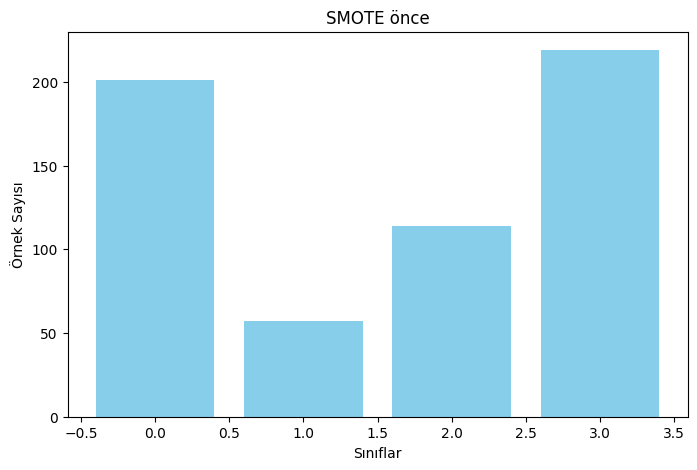

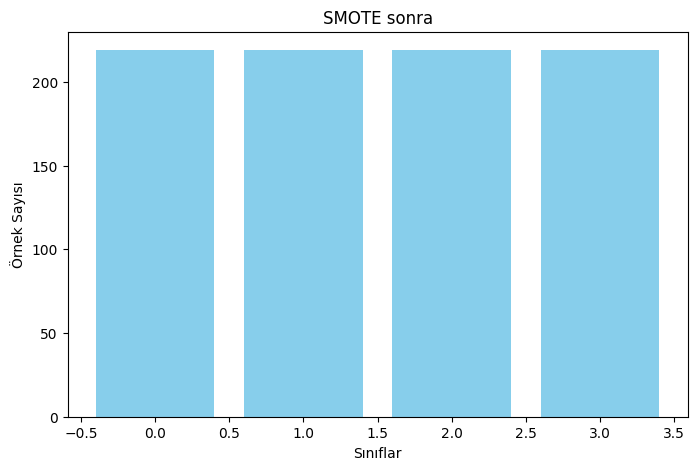

In [ ]:
def plot_class_distribution(y, title="Sınıf Dağılımı"):
    counter = Counter(y)
    classes = list(counter.keys())
    counts = list(counter.values())
    plt.figure(figsize=(8,5))
    plt.bar(classes, counts, color='skyblue')
    plt.title(title)
    plt.xlabel("Sınıflar")
    plt.ylabel("Örnek Sayısı")
    plt.show()

# Kullanımı
plot_class_distribution(y_train, "SMOTE önce")
plot_class_distribution(y_train_resampled, "SMOTE sonra")


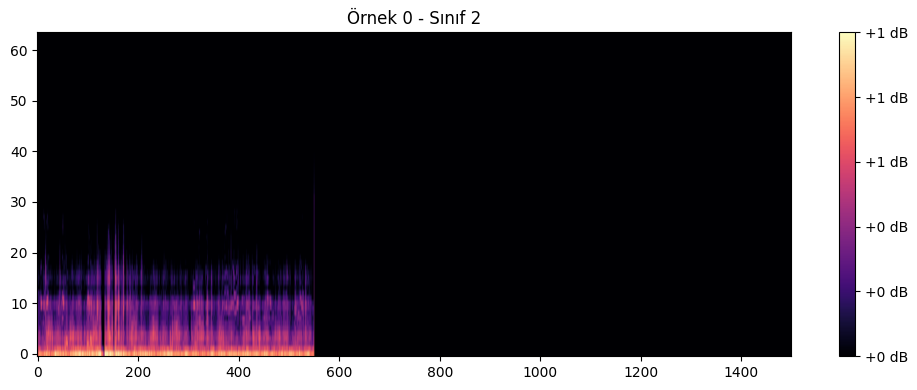

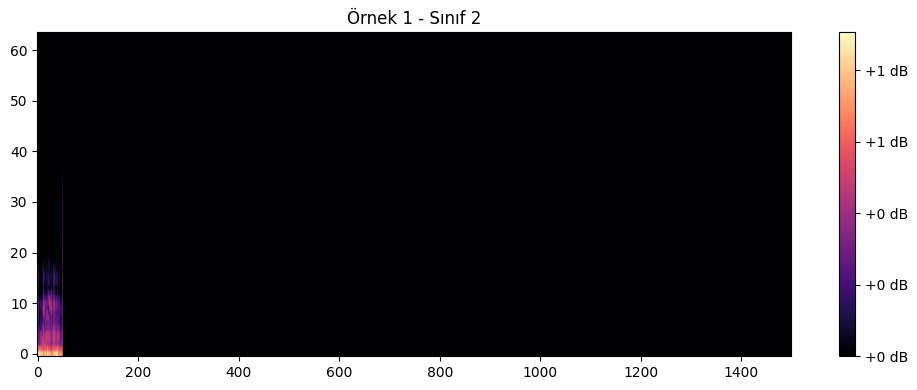

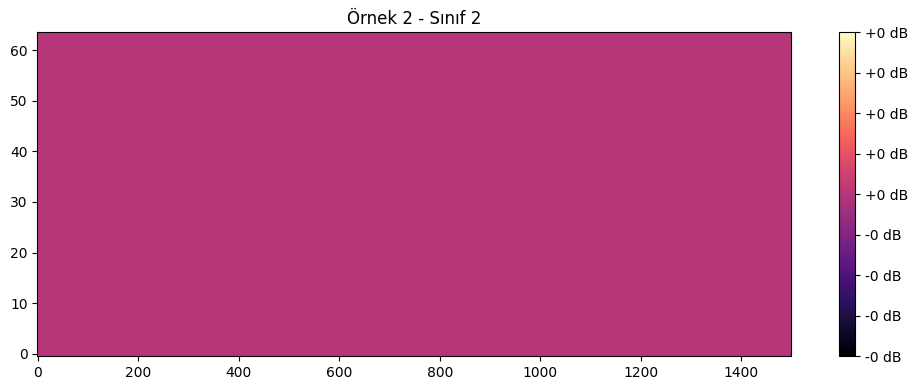

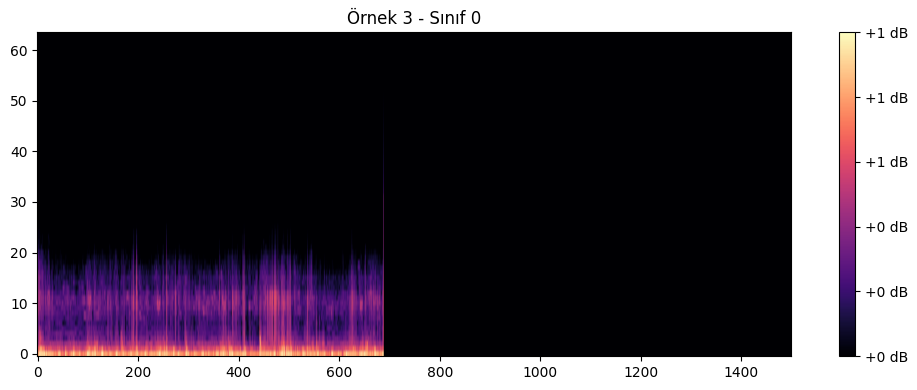

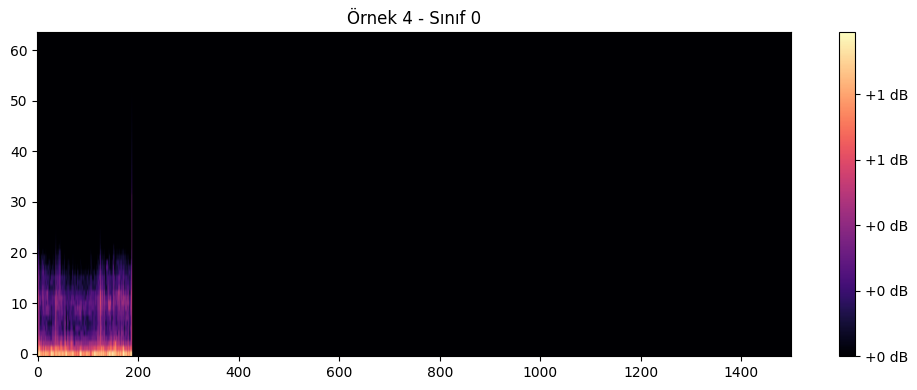

In [ ]:
def plot_mel_spectrogram(mel_spec, title=None):
    plt.figure(figsize=(10, 4))
    plt.imshow(mel_spec.squeeze(), origin='lower', aspect='auto', cmap='magma')
    if title:
        plt.title(title)
    plt.colorbar(format='%+2.0f dB')
    plt.tight_layout()
    plt.show()

# Örnek 5 Mel-spectrogram çizimi
for i in range(5):
    plot_mel_spectrogram(X_train_resampled[i], title=f"Örnek {i} - Sınıf {y_train_resampled[i]}")


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

num_classes = len(label2idx)

model = Sequential([
    Input(shape=(64, 1500, 1)),  # MFCC veya benzeri 2D özellik haritası
    Conv2D(32, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 1498, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 62, 1498, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 749, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 747, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 29, 747, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 373, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 371, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 371, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 185, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 142080)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    18,186,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,280,452 (69.73 MB)

 Trainable params: 18,280,004 (69.73 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', save_best_only=True),
    ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
]


In [ ]:
history = model.fit(
    X_train_resampled,
    y_train_resampled,
    epochs=70,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)


Epoch 1/70
28/28 ━━━━━━━━━━━━━━━━━━━━ 267s 9s/step - accuracy: 0.2905 - loss: 23.9071 - val_accuracy: 0.0952 - val_loss: 4.1257 - learning_rate: 0.0010
Epoch 2/70
28/28 ━━━━━━━━━━━━━━━━━━━━ 251s 9s/step - accuracy: 0.3068 - loss: 3.4473 - val_accuracy: 0.0952 - val_loss: 5.3582 - learning_rate: 0.0010
Epoch 3/70
28/28 ━━━━━━━━━━━━━━━━━━━━ 273s 9s/step - accuracy: 0.3520 - loss: 1.5544 - val_accuracy: 0.0952 - val_loss: 8.1591 - learning_rate: 0.0010
Epoch 4/70
28/28 ━━━━━━━━━━━━━━━━━━━━ 250s 9s/step - accuracy: 0.3415 - loss: 1.7827 - val_accuracy: 0.0952 - val_loss: 11.0690 - learning_rate: 0.0010
Epoch 5/70
28/28 ━━━━━━━━━━━━━━━━━━━━ 274s 9s/step - accuracy: 0.3352 - loss: 1.3317 - val_accuracy: 0.0952 - val_loss: 8.7036 - learning_rate: 0.0010
Epoch 6/70
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.2885 - loss: 1.3488
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
28/28 ━━━━━━━━━━━━━━━━━━━━ 254s 9s/step - accuracy: 0.2887 - loss: 1.3489 - val_accu

In [ ]:
from collections import Counter
print(Counter(y_val))


Counter({np.int64(3): 48, np.int64(0): 42, np.int64(2): 24, np.int64(1): 12})


# Transfer Learning

In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
from skimage.transform import resize
import numpy as np

def preprocess_spectrogram(spectrogram, size=(224, 224)):
    # Eğer son boyut 1 ise squeeze yap
    if spectrogram.ndim == 3 and spectrogram.shape[-1] == 1:
        spectrogram = spectrogram.squeeze(-1)  # (H, W)

    # Resize ile hedef boyuta getir
    spectrogram_resized = resize(spectrogram, size, mode='constant')

    # Tip dönüşümü (float32)
    spectrogram_resized = spectrogram_resized.astype(np.float32)

    # Tek kanaldan 3 kanala çoğalt
    spectrogram_rgb = np.stack([spectrogram_resized]*3, axis=-1)  # (224,224,3)

    return spectrogram_rgb

X_train_resized = np.array([preprocess_spectrogram(x) for x in X_train_resampled])
X_val_resized = np.array([preprocess_spectrogram(x) for x in X_val])
X_test_resized = np.array([preprocess_spectrogram(x) for x in X_test])

print(f"X_train_resized shape: {X_train_resized.shape}")  # (N, 224, 224, 3)
print(f"X_val_resized shape: {X_val_resized.shape}")
print(f"X_test_resized shape: {X_test_resized.shape}")



X_train_resized shape: (876, 224, 224, 3)
X_val_resized shape: (126, 224, 224, 3)
X_test_resized shape: (129, 224, 224, 3)


In [ ]:


base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
for layer in base_model.layers:
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(4, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])



In [ ]:
# EarlyStopping callback
early_stopping = EarlyStopping(monitor='val_loss',
                               patience=5,  # 5 epoch boyunca iyileşme olmazsa dur
                               restore_best_weights=True,
                               verbose=1)


In [ ]:
history = model.fit(
    X_train_resized, y_train_resampled,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_resized, y_val)
)


Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 102s 3s/step - accuracy: 0.2696 - loss: 1.4165 - val_accuracy: 0.3333 - val_loss: 1.3905
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 128s 3s/step - accuracy: 0.2581 - loss: 1.4015 - val_accuracy: 0.3810 - val_loss: 1.3861
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 74s 3s/step - accuracy: 0.2669 - loss: 1.3927 - val_accuracy: 0.0952 - val_loss: 1.3945
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.2659 - loss: 1.3931 - val_accuracy: 0.3333 - val_loss: 1.3849
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.2780 - loss: 1.3894 - val_accuracy: 0.3333 - val_loss: 1.3703
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 82s 3s/step - accuracy: 0.2409 - loss: 1.3973 - val_accuracy: 0.1905 - val_loss: 1.3803
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 80s 3s/step - accuracy: 0.2481 - loss: 1.3914 - val_accuracy: 0.0952 - val_loss: 1.3883
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 83s 3s/step - accuracy: 0.2414 - loss: 1.3914 - val_accuracy: 0.3730 - val_los

In [ ]:
# Örneğin son 10 katmanı aç
for layer in base_model.layers[-10:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_finetune = model.fit(
    X_train_resized, y_train_resampled,
    epochs=10,
    batch_size=32,
    validation_data=(X_val_resized, y_val)
)


Epoch 1/10
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.2425 - loss: 1.6321

KeyboardInterrupt: 

# Sonuçları

In [ ]:
model.save('4sınıflı_slidingWindow_CNN.keras')


In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f'Test doğruluğu: {test_acc:.4f}')

2/2 - 2s - 804ms/step - accuracy: 0.8605 - loss: 1.2795
Test doğruluğu: 0.8605


5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 596ms/step
Confusion Matrix:
 [[41  0  0  4]
 [ 7  4  0  1]
 [12  0  6  6]
 [14  0  0 34]]


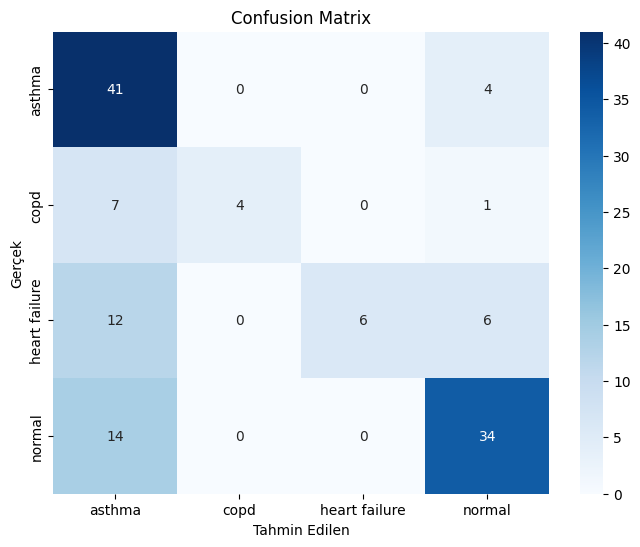

Classification Report:
                precision    recall  f1-score   support

       asthma       0.55      0.91      0.69        45
         copd       1.00      0.33      0.50        12
heart failure       1.00      0.25      0.40        24
       normal       0.76      0.71      0.73        48

     accuracy                           0.66       129
    macro avg       0.83      0.55      0.58       129
 weighted avg       0.75      0.66      0.63       129



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Test verisi üzerinde tahmin yap
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Confusion matrix görselleştirme
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label2idx.keys(), yticklabels=label2idx.keys())
plt.xlabel('Tahmin Edilen')
plt.ylabel('Gerçek')
plt.title('Confusion Matrix')
plt.show()

# Sınıflandırma raporu
report = classification_report(y_test, y_pred, target_names=list(label2idx.keys()))
print("Classification Report:\n", report)


In [ ]:
from tensorflow.keras.models import load_model

model = load_model('4sınıflı_slidingWindow_CNN.keras')
model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 62, 749, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 62, 749, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 31, 374, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 29, 372, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 29, 372, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 186, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 184, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 12, 184, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 6, 92, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 70656)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     9,044,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,413,646 (104.57 MB)

 Trainable params: 9,137,732 (34.86 MB)

 Non-trainable params: 448 (1.75 KB)

 Optimizer params: 18,275,466 (69.72 MB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# (64, 751, 1) → (64, 751, 3)
X_train_3ch = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X_train))
X_val_3ch   = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X_val))
X_test_3ch  = tf.image.grayscale_to_rgb(tf.convert_to_tensor(X_test))

input_shape = (64, 751, 3)



# PANNs Pipeline

In [ ]:
!git clone https://github.com/qiuqiangkong/panns_demo.git
%cd panns_demo


In [ ]:
import torch
from pytorch_utils import move_data_to_device

model = torch.hub.load('qiuqiangkong/panns_demo', 'Cnn14', pretrained=True)
model.eval()


In [ ]:
import os
import numpy as np
import torchaudio
import torch

def extract_label_from_filename(filename):
    # Kendi etiket çıkarım fonksiyonunu buraya yaz
    # Örnek: "label_123.wav" -> "label"
    return filename.split('_')[0]

def sliding_window_raw(audio, max_len=160000, stride=64000):
    """
    Audio: Tensor (1, N)
    """
    windows = []
    total_len = audio.shape[1]
    for start in range(0, total_len, stride):
        end = start + max_len
        if end <= total_len:
            window = audio[:, start:end]
        else:
            window = audio[:, start:]
            pad_width = max_len - window.shape[1]
            window = torch.nn.functional.pad(window, (0, pad_width))
        windows.append(window)
    return windows

def load_data_sliding_raw(folder_path, max_len=160000, stride=64000):
    X = []
    y = []
    labels_set = set()
    wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]

    for filename in wav_files:
        label = extract_label_from_filename(filename)
        if label is not None:
            labels_set.add(label)

    label2idx = {label: idx for idx, label in enumerate(sorted(labels_set))}
    print(f"Bulunan sınıflar ve indeksleri: {label2idx}")

    for filename in wav_files:
        label = extract_label_from_filename(filename)
        if label is None:
            print(f"⚠️ Etiket çıkarılamadı, atlanıyor: {filename}")
            continue

        file_path = os.path.join(folder_path, filename)
        print(f"📄 İşleniyor: {filename} (Etiket: {label})")

        waveform, sr = torchaudio.load(file_path)
        if sr != 16000:
            resample = torchaudio.transforms.Resample(sr, 16000)
            waveform = resample(waveform)

        windows = sliding_window_raw(waveform, max_len=max_len, stride=stride)
        print(f"🔹 Üretilen Sliding Window Sayısı: {len(windows)}\n")

        label_idx = label2idx[label]
        X.extend(windows)
        y.extend([label_idx] * len(windows))

    print(f"\n✅ Toplam örnek sayısı: {len(X)}")

    return X, y, label2idx


In [ ]:
from torch.utils.data import Dataset, DataLoader

class AudioDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Örnek kullanım
X, y, label2idx = load_data_sliding_raw('dataset_path')
dataset = AudioDataset(X, y)

from sklearn.model_selection import train_test_split
train_idx, val_idx = train_test_split(np.arange(len(dataset)), test_size=0.2, stratify=y)

train_dataset = torch.utils.data.Subset(dataset, train_idx)
val_dataset = torch.utils.data.Subset(dataset, val_idx)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)


In [ ]:
import torch
import torch.nn as nn

model = torch.hub.load('qiuqiangkong/panns_demo', 'Cnn14', pretrained=True)
model.fc_audioset = nn.Linear(model.fc_audioset.in_features, len(label2idx))  # Kendi sınıf sayın
model.sigmoid = nn.Softmax(dim=1)  # Çok sınıflı problem için softmax

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


In [ ]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 20

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in train_loader:
        inputs, labels = batch
        inputs = inputs.squeeze(1).to(device)  # (batch, 160000)
        labels = labels.to(device)

        outputs = model(inputs)['clipwise_output']

        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for batch in val_loader:
            inputs, labels = batch
            inputs = inputs.squeeze(1).to(device)
            labels = labels.to(device)

            outputs = model(inputs)['clipwise_output']
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}, Val Acc: {val_acc:.4f}")


# Farklı augmente edilmiş yöntem

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
from collections import defaultdict
from glob import glob

# Sınıf isimleri dosya adından çıkarılıyor
def get_class_name(file_name):
    return file_name.split("_")[1].split(",")[0].strip().lower()

# Tüm train dosyalarını bul
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"
train_files = glob(os.path.join(train_dir, "*.wav"))

# Sınıflara göre grupla
class_file_map = defaultdict(list)
for file in train_files:
    class_name = get_class_name(os.path.basename(file))
    class_file_map[class_name].append(file)

# En büyük sınıf sayısını bul (otomatik hedef)
max_class_size = max(len(v) for v in class_file_map.values())
print(f"🔎 Hedef augmentasyon adedi: {max_class_size}")

# Eksik sınıfları tespit et
minor_classes = {k: v for k, v in class_file_map.items() if len(v) < max_class_size}

print("Eksik sınıflar:")
for k, v in minor_classes.items():
    print(f"{k}: {len(v)} dosya")

# Augment fonksiyonu
def augment_and_save(file_path, save_dir, class_name, augment_index):
    y, sr = librosa.load(file_path, sr=None)
    y_aug = y.copy()

    mod = augment_index % 5
    if mod == 0:
        # Time Stretch
        rate = 0.8 + 0.4 * np.random.rand()  # 0.8 ile 1.2 arasında
        y_aug = librosa.effects.time_stretch(y_aug, rate=rate)
    elif mod == 1:
        # Pitch Shift
        n_steps = np.random.uniform(-4, 4)
        y_aug = librosa.effects.pitch_shift(y_aug, sr=sr, n_steps=n_steps)
    elif mod == 2:
        # Gaussian Noise
        noise_amp = 0.005 * np.random.uniform(0.8, 1.2)
        y_aug = y_aug + noise_amp * np.random.randn(len(y_aug))
    elif mod == 3:
        # Time Shift
        shift = np.random.randint(-int(0.1 * len(y_aug)), int(0.1 * len(y_aug)))
        y_aug = np.roll(y_aug, shift)
    elif mod == 4:
        # Gain (volume scaling)
        gain = np.random.uniform(0.7, 1.3)
        y_aug = y_aug * gain

    # Dosya kaydet
    base = os.path.basename(file_path).replace(".wav", f"_aug{augment_index}.wav")
    save_path = os.path.join(save_dir, base)
    sf.write(save_path, y_aug, sr)
    print(f"✔ Augment edildi: {save_path}")

# Augment işlemi
for class_name, files in minor_classes.items():
    mevcut = len(files)
    eksik = max_class_size - mevcut
    print(f"\n📌 {class_name} sınıfı için {eksik} augment gerekli.")
    augment_index = 0
    while eksik > 0:
        for file_path in files:
            if eksik <= 0:
                break
            augment_and_save(file_path, train_dir, class_name, augment_index)
            eksik -= 1
            augment_index += 1


🔎 Hedef augmentasyon adedi: 73
Eksik sınıflar:
heart failure: 38 dosya
asthma: 67 dosya
copd: 19 dosya

📌 heart failure sınıfı için 35 augment gerekli.
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4/DP14_Heart Failure,C,A R M,54,M_aug0.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4/BP67_heart failure,Crep,P R L ,24,F_aug1.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4/BP40_heart failure,Crep,A R M,26,M_aug2.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4/BP39_heart failure,Crep,P R L ,67,M_aug3.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4/DP45_heart failure,Crep,P R L ,30,M_aug4.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4/EP90_heart failure,Crep,P L M,74,F_aug5.wav
✔ Augment edildi: /content/drive/My Drive/Colab Notebooks/akciger-se

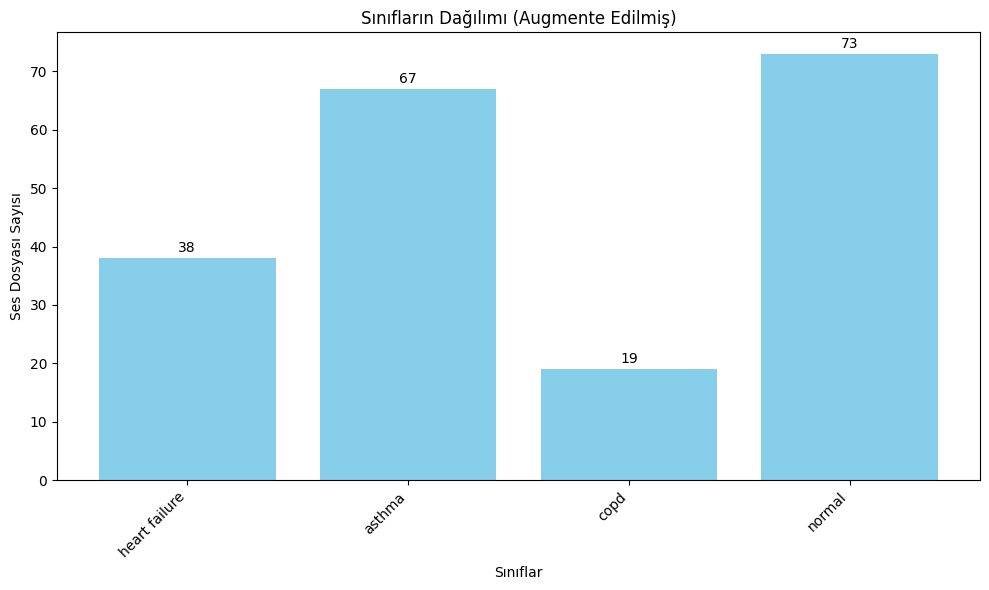

In [ ]:
import os
import matplotlib.pyplot as plt
# Etiketleri saymak için sözlük
u_class_counts = {}
train_dir = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"
# Dosyaları dolaş
for file_name in os.listdir(train_dir):
    if file_name.endswith(".wav"):
        file_name = file_name.strip()

        try:
            # Etiketi çıkar (örnek: EP69_pneumonia,Bronchial,P R L ,64,M_aug2.wav -> pneumonia)
            raw_label = file_name.split('_')[1].split(',')[0].strip().lower()

            # Etiketi normalize et
            if 'asthma and lung fibrosis' in raw_label:
                label_name = 'asthma'
            elif 'heart failure + copd' in raw_label or 'heart failure + lung fibrosis' in raw_label:
                label_name = 'heart failure'
            elif 'asthma' in raw_label:
                label_name = 'asthma'
            elif 'bron' in raw_label:
                label_name = 'bron'
            elif 'copd' in raw_label:
                label_name = 'copd'
            elif 'heart failure' in raw_label:
                label_name = 'heart failure'
            elif 'lung fibrosis' in raw_label:
                label_name = 'lung fibrosis'
            elif 'pleural effusion' in raw_label or 'plueral effusion' in raw_label:
                label_name = 'plueral effusion'
            elif 'pneumonia' in raw_label:
                label_name = 'pneumonia'
            elif raw_label == 'n':
                label_name = 'normal'
            else:
                print(f"Bilinmeyen sınıf: {raw_label}")
                continue

            # Sözlüğe ekle
            if label_name in u_class_counts:
                u_class_counts[label_name] += 1
            else:
                u_class_counts[label_name] = 1

        except Exception as e:
            print(f"Hata: {file_name} -> {e}")

# Grafik oluşturma
labels = list(u_class_counts.keys())
counts = list(u_class_counts.values())

plt.figure(figsize=(10, 6))
plt.bar(labels, counts, color='skyblue')
for i, count in enumerate(counts):
    plt.text(i, count + 0.5, str(count), ha='center', va='bottom', fontsize=10)
plt.title('Sınıfların Dağılımı (Augmente Edilmiş)')
plt.xlabel('Sınıflar')
plt.ylabel('Ses Dosyası Sayısı')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
def extract_label_from_filename(filename):
    # .wav uzantısını kontrol et
    if not filename.endswith('.wav'):
        return None

    # Dosya adını ayır
    basename = os.path.splitext(filename)[0]
    parts = basename.split("_")
    if len(parts) < 2:
        print(f"Beklenmeyen format: {filename}")
        return None

    diagnosis = parts[1].strip().lower()

    # Bazı dosyalarda tanı 'n,n,xxx' gibi olabilir
    if diagnosis.startswith('n,n'):
        return 'normal'

    # Hastalık etiketini belirle
    if 'asthma and lung fibrosis' in diagnosis:
        return 'asthma'
    elif 'heart failure + copd' in diagnosis or 'heart failure + lung fibrosis' in diagnosis:
        return 'heart failure'
    elif 'asthma' in diagnosis:
        return 'asthma'
    elif 'bron' in diagnosis:
        return 'bron'
    elif 'copd' in diagnosis:
        return 'copd'
    elif 'heart failure' in diagnosis:
        return 'heart failure'
    elif 'lung fibrosis' in diagnosis:
        return 'lung fibrosis'
    elif 'pleural effusion' in diagnosis or 'plueral effusion' in diagnosis:
        return 'pleural effusion'  # düzeltme: "plueral" → "pleural"
    elif 'pneumonia' in diagnosis:
        return 'pneumonia'
    elif diagnosis == 'n':
        return 'normal'
    else:
        print(f"Eşleşmeyen tanı: {diagnosis} | Dosya: {filename}")
        return None


In [ ]:
from glob import glob
import pandas as pd
# Klasördeki .wav dosyalarını listele
filepaths = [f for f in os.listdir(train_dir) if f.endswith('.wav')]

# Her bir dosya için etiket çıkar
data = []
for filename in filepaths:
    label = extract_label_from_filename(filename)
    if label:  # sadece geçerli label'lar
        data.append({"filename": filename, "label": label})

# DataFrame olarak göster
df = pd.DataFrame(data)
print(df.head(10))  # ilk 10 örneği göster

                                  filename          label
0      DP14_Heart Failure,C,A R M,54,M.wav  heart failure
1           EP35_Asthma,E W,A R L,38,M.wav         asthma
2          DP101_Asthma,E W,P L M,12,F.wav         asthma
3  BP67_heart failure,Crep,P R L ,24,F.wav  heart failure
4             EP62_COPD,E W,P L M,53,M.wav           copd
5                  DP81_N,N,P L U,33,M.wav         normal
6                  BP31_N,N,P L M,27,F.wav         normal
7             BP25_copd,E W,P L L,76,M.wav           copd
8   BP40_heart failure,Crep,A R M,26,M.wav  heart failure
9                  DP32_N,N,A R L,30,M.wav         normal


In [ ]:
def extract_mel_spectrogram(file_path,
                            max_len=751,
                            sr=22050,
                            n_mels=64,
                            n_fft=1024,
                            hop_length=512,
                            normalize_method='minmax'):
    try:
        # Ses dosyasını yükle
        y, sr = librosa.load(file_path, sr=sr)

        # Boş ses kontrolü
        if y.size == 0:
            print(f"❌ Boş ses dosyası: {file_path}")
            return None

        # Mel-spectrogram çıkarımı
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                                   n_fft=n_fft, hop_length=hop_length)

        # dB cinsine dönüştür
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # --- Normalize Et ---
        if normalize_method == 'minmax':
            mel_spec_db -= mel_spec_db.min()
            max_val = mel_spec_db.max()
            if max_val != 0:
                mel_spec_db /= max_val
            else:
                print(f"⚠️ Normalize edilemeyen spectrogram (sıfır enerji): {file_path}")
                return None

        elif normalize_method == 'dbscale':
            mel_spec_db = np.clip(mel_spec_db, a_min=-80, a_max=0)
            mel_spec_db = (mel_spec_db + 80) / 80

        elif normalize_method == 'standard':
            mean = np.mean(mel_spec_db)
            std = np.std(mel_spec_db)
            if std != 0:
                mel_spec_db = (mel_spec_db - mean) / std
            else:
                print(f"⚠️ Normalize edilemeyen spectrogram (std=0): {file_path}")
                return None

        else:
            raise ValueError(f"Geçersiz normalize yöntemi: {normalize_method}")

        # NaN kontrolü
        if np.isnan(mel_spec_db).any():
            print(f"⚠️ NaN içeren spectrogram: {file_path}")
            return None

        # Padding / kırpma
        if mel_spec_db.shape[1] < max_len:
            pad_width = max_len - mel_spec_db.shape[1]
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
        else:
            mel_spec_db = mel_spec_db[:, :max_len]

        return mel_spec_db

    except Exception as e:
        print(f"❌ Hata oluştu ({file_path}): {e}")
        return None



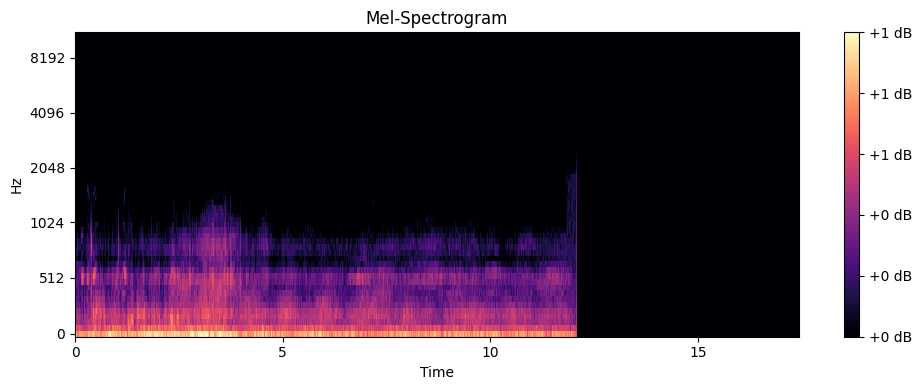

In [ ]:
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Test etmek için bir dosya yolu (örnek: train klasöründen bir dosya seç)
test_file = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4/DP14_Heart Failure,C,A R M,54,M_aug0.wav"

# Mel spectrogramı çıkar
mel_spec_db = extract_mel_spectrogram(test_file)

# Eğer çıktı varsa görselleştir
if mel_spec_db is not None:
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spec_db, sr=22050, hop_length=512,
                             x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title('Mel-Spectrogram')
    plt.tight_layout()
    plt.show()
else:
    print("Mel spektrogram üretilemedi.")


In [ ]:
def sliding_window(mel_spec, max_len=751, stride=751):
    windows = []
    total_len = mel_spec.shape[1]
    for start in range(0, total_len, stride):
        end = start + max_len
        if end <= total_len:
            window = mel_spec[:, start:end]
        else:
            window = mel_spec[:, start:]
            pad_width = max_len - window.shape[1]
            window = np.pad(window, ((0, 0), (0, pad_width)), mode='constant')
        windows.append(window)
    return windows

def load_data_from_folder_sliding(folder_path, max_len=751, stride=300):
    X = []
    y = []
    labels_set = set()
    wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]

    # Önce tüm dosyaların etiketlerini çıkar ve set oluştur
    for filename in wav_files:
        label = extract_label_from_filename(filename)
        if label is not None:
            labels_set.add(label)

    label2idx = {label: idx for idx, label in enumerate(sorted(labels_set))}
    print(f"Bulunan sınıflar ve indeksleri: {label2idx}")

    # Dosyaları işle
    for filename in wav_files:
        label = extract_label_from_filename(filename)
        if label is None:
            continue

        file_path = os.path.join(folder_path, filename)
        print(f"📄 İşleniyor: {filename} (Etiket: {label})")

        mel_spec = extract_mel_spectrogram(file_path, max_len=max_len)
        print(f"🔸 Mel Spectrogram Boyutu: {mel_spec.shape}")

        windows = sliding_window(mel_spec, max_len=max_len, stride=stride)
        print(f"🔹 Üretilen Sliding Window Sayısı: {len(windows)}\n")

        label_idx = label2idx[label]
        X.extend(windows)
        y.extend([label_idx] * len(windows))

    X = np.array(X)
    y = np.array(y)

    print(f"\n✅ Toplam örnek sayısı: {X.shape[0]}")
    print(f"✅ X shape: {X.shape}")
    print(f"✅ y shape: {y.shape}")

    X = X[..., np.newaxis]

    return X, y, label2idx


In [ ]:
train_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"
val_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4"
test_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4"


X_train, y_train, label2idx = load_data_from_folder_sliding(train_folder, max_len=751, stride=500)
X_val, y_val, _ = load_data_from_folder_sliding(val_folder, max_len=751, stride=500)
X_test, y_test, _ = load_data_from_folder_sliding(test_folder, max_len=751, stride=500)


Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}
📄 İşleniyor: DP14_Heart Failure,C,A R M,54,M.wav (Etiket: heart failure)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 2

📄 İşleniyor: EP35_Asthma,E W,A R L,38,M.wav (Etiket: asthma)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 2

📄 İşleniyor: DP101_Asthma,E W,P L M,12,F.wav (Etiket: asthma)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 2

📄 İşleniyor: BP67_heart failure,Crep,P R L ,24,F.wav (Etiket: heart failure)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 2

📄 İşleniyor: EP62_COPD,E W,P L M,53,M.wav (Etiket: copd)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 2

📄 İşleniyor: DP81_N,N,P L U,33,M.wav (Etiket: normal)
🔸 Mel Spectrogram Boyutu: (64, 751)
🔹 Üretilen Sliding Window Sayısı: 2

📄 İşleniyor: BP31_N,N,P L M,27,F.wav (Etiket: normal)
🔸 Mel Spectrogram Boyutu: (64, 751

In [ ]:
def load_data_from_folder_noslide(folder_path, max_len=751):
    X = []
    y = []
    labels_set = set()
    wav_files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]

    # Etiketleri tanımla
    for filename in wav_files:
        label = extract_label_from_filename(filename)
        if label is not None:
            labels_set.add(label)

    label2idx = {label: idx for idx, label in enumerate(sorted(labels_set))}
    print(f"Bulunan sınıflar ve indeksleri: {label2idx}")

    for filename in wav_files:
        label = extract_label_from_filename(filename)
        if label is None:
            continue

        file_path = os.path.join(folder_path, filename)
        print(f"📄 İşleniyor: {filename} (Etiket: {label})")

        # Mel spektrogram çıkar
        mel_spec = extract_mel_spectrogram(file_path, max_len=max_len)
        print(f"🔸 Mel Spectrogram Boyutu: {mel_spec.shape}")

        # Tek bir örnek ekle
        label_idx = label2idx[label]
        X.append(mel_spec)
        y.append(label_idx)

    X = np.array(X)[..., np.newaxis]  # (num_samples, 64, 751, 1)
    y = np.array(y)

    print(f"\n✅ Toplam örnek sayısı: {X.shape[0]}")
    print(f"✅ X shape: {X.shape}")
    print(f"✅ y shape: {y.shape}")

    return X, y, label2idx


In [ ]:
import os
train_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"
val_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4"
test_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4"

X_train, y_train, label2idx = load_data_from_folder_noslide(train_folder)
X_val, y_val, _ = load_data_from_folder_noslide(val_folder)
X_test, y_test, _ = load_data_from_folder_noslide(test_folder)


Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}
📄 İşleniyor: DP14_Heart Failure,C,A R M,54,M.wav (Etiket: heart failure)
🔸 Mel Spectrogram Boyutu: (64, 751)
📄 İşleniyor: EP35_Asthma,E W,A R L,38,M.wav (Etiket: asthma)
🔸 Mel Spectrogram Boyutu: (64, 751)
📄 İşleniyor: DP101_Asthma,E W,P L M,12,F.wav (Etiket: asthma)
🔸 Mel Spectrogram Boyutu: (64, 751)
📄 İşleniyor: BP67_heart failure,Crep,P R L ,24,F.wav (Etiket: heart failure)
🔸 Mel Spectrogram Boyutu: (64, 751)
📄 İşleniyor: EP62_COPD,E W,P L M,53,M.wav (Etiket: copd)
🔸 Mel Spectrogram Boyutu: (64, 751)
📄 İşleniyor: DP81_N,N,P L U,33,M.wav (Etiket: normal)
🔸 Mel Spectrogram Boyutu: (64, 751)
📄 İşleniyor: BP31_N,N,P L M,27,F.wav (Etiket: normal)
🔸 Mel Spectrogram Boyutu: (64, 751)
📄 İşleniyor: BP25_copd,E W,P L L,76,M.wav (Etiket: copd)
🔸 Mel Spectrogram Boyutu: (64, 751)
📄 İşleniyor: BP40_heart failure,Crep,A R M,26,M.wav (Etiket: heart failure)
🔸 Mel Spectrogram Boyutu: (64, 751)
📄 İşleniyor: DP

In [ ]:
y_train_oh = tf.keras.utils.to_categorical(y_train, num_classes=4)
y_val_oh = tf.keras.utils.to_categorical(y_val, num_classes=4)

In [ ]:
print("Train Etiket dağılımı:")
unique, counts = np.unique(y_train, return_counts=True)
for i, count in zip(unique, counts):
    print(f"{i} ({list(label2idx.keys())[i]}): {count} örnek")


Train Etiket dağılımı:
0 (asthma): 146 örnek
1 (copd): 146 örnek
2 (heart failure): 146 örnek
3 (normal): 146 örnek


In [ ]:
print(f"X_train boyutu: {X_train.shape}")
print(f"y_train boyutu: {y_train.shape}")

X_train boyutu: (584, 64, 751, 1)
y_train boyutu: (584,)


In [ ]:
print("Val Etiket dağılımı:")
unique, counts = np.unique(y_val, return_counts=True)
for i, count in zip(unique, counts):
    print(f"{i} ({list(label2idx.keys())[i]}): {count} örnek")


Val Etiket dağılımı:
0 (asthma): 28 örnek
1 (copd): 8 örnek
2 (heart failure): 16 örnek
3 (normal): 32 örnek


In [ ]:
print("Test Etiket dağılımı:")
unique, counts = np.unique(y_test, return_counts=True)
for i, count in zip(unique, counts):
    print(f"{i} ({list(label2idx.keys())[i]}): {count} örnek")


Test Etiket dağılımı:
0 (asthma): 30 örnek
1 (copd): 8 örnek
2 (heart failure): 16 örnek
3 (normal): 32 örnek


In [ ]:
np.bincount(y_train)

array([146, 146, 146, 146])

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Conv1D, MaxPooling2D, Dropout, Flatten, Dense, BatchNormalization, Input, Activation, Add, GlobalAveragePooling2D
from tensorflow.keras.models import Model
import tensorflow as tf


# MEL SEPECTROGRAM CNN SONUÇLARI

In [ ]:
model = Sequential([
    Input(shape=(64, 751, 1)),  # Mel-spectrogram giriş boyutu

    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')  # 4 sınıf: asthma, copd, heart failure, normal
])
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 751, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 751, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 375, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 375, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 375, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 375, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 187, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 187, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 187, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 187, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 93, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 93, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 95232)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    24,379,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,474,244 (93.36 MB)

 Trainable params: 24,473,796 (93.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('en_iyisi.keras', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=100,
                    batch_size=32,
                    callbacks=callbacks)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 125s 7s/step - accuracy: 0.2963 - loss: 3.2928 - val_accuracy: 0.3810 - val_loss: 1.5778 - learning_rate: 6.2500e-06
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 133s 6s/step - accuracy: 0.3238 - loss: 2.2267 - val_accuracy: 0.1905 - val_loss: 1.8516 - learning_rate: 6.2500e-06
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 140s 6s/step - accuracy: 0.3244 - loss: 1.8368 - val_accuracy: 0.1905 - val_loss: 2.1389 - learning_rate: 6.2500e-06
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 113s 6s/step - accuracy: 0.3336 - loss: 1.5936 - val_accuracy: 0.1905 - val_loss: 2.3794 - learning_rate: 6.2500e-06
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 116s 6s/step - accuracy: 0.3465 - loss: 1.4314 - val_accuracy: 0.1905 - val_loss: 2.6579 - learning_rate: 6.2500e-06
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 145s 6s/step - accuracy: 0.3473 - loss: 1.4086 - val_accuracy: 0.1905 - val_loss: 2.8576 - learning_rate: 6.2500e-06
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 135s 6s/step - accuracy: 

In [ ]:
print(np.unique(y_train), y_train.dtype)
print(X_train.shape)  # → (örnek_sayısı, 64, 751, 1)


[0 1 2 3] int64
(584, 64, 751, 1)


In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history):
    plt.figure(figsize=(12, 5))

    # Doğruluk
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Eğitim Doğruluğu')
    plt.plot(history.history['val_accuracy'], label='Doğrulama Doğruluğu')
    plt.title('Model Doğruluğu')
    plt.xlabel('Epoch')
    plt.ylabel('Doğruluk')
    plt.legend()

    # Kayıp
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Eğitim Kaybı')
    plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
    plt.title('Model Kaybı')
    plt.xlabel('Epoch')
    plt.ylabel('Kayıp')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_history(history)


In [ ]:
# Test setinde modelin başarısı
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\n📊 Test Doğruluğu: {test_accuracy:.4f}")
print(f"📉 Test Kaybı: {test_loss:.4f}")


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np

# Tahminler
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Sınıf etiketlerini geri döndürmek için:
idx2label = {v: k for k, v in label2idx.items()}

# Sınıflandırma raporu
print("\n📝 Sınıflandırma Raporu:")
print(classification_report(y_test, y_pred, target_names=[idx2label[i] for i in range(len(idx2label))]))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=idx2label.values(), yticklabels=idx2label.values(), cmap='Blues')
plt.title("Confusion Matrix")
plt.ylabel("Gerçek Etiket")
plt.xlabel("Tahmin Edilen Etiket")
plt.show()


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay

# Etiketleri binarize et
y_test_bin = label_binarize(y_test, classes=list(range(len(label2idx))))

# ROC eğrisi çiz
plt.figure(figsize=(10, 8))
for i in range(y_test_bin.shape[1]):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    label = f"{idx2label[i]} (AUC = {roc_auc:.2f})"
    plt.plot(fpr, tpr, label=label)

plt.plot([0, 1], [0, 1], 'k--')  # random çizgisi
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Eğrisi (Çoklu Sınıf)')
plt.legend(loc='lower right')
plt.grid()
plt.show()


In [ ]:
def residual_block(x, filters, stride=1, downsample=False):
    shortcut = x

    # 1. Conv + BN + ReLU
    x = Conv2D(filters, kernel_size=3, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    # 2. Conv + BN
    x = Conv2D(filters, kernel_size=3, strides=1, padding='same')(x)
    x = BatchNormalization()(x)

    # Shortcut ayarı (boyut eşleştirme)
    if downsample:
        shortcut = Conv2D(filters, kernel_size=1, strides=stride, padding='same')(shortcut)
        shortcut = BatchNormalization()(shortcut)

    # Toplama + ReLU
    x = Add()([x, shortcut])
    x = Activation('relu')(x)

    return x


In [ ]:
def build_resnet18(input_shape=(64, 751, 1), num_classes=4):
    inputs = Input(shape=input_shape)

    x = Conv2D(64, kernel_size=7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)

    x = tf.keras.layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    # Residual bloklar (18 katman için 2-2-2-2 blok yapısı)
    x = residual_block(x, 64)
    x = residual_block(x, 64)

    x = residual_block(x, 128, stride=2, downsample=True)
    x = residual_block(x, 128)

    x = residual_block(x, 256, stride=2, downsample=True)
    x = residual_block(x, 256)

    x = residual_block(x, 512, stride=2, downsample=True)
    x = residual_block(x, 512)

    x = GlobalAveragePooling2D()(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model


In [ ]:
model = build_resnet18()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 751,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 32, 376,   │      3,200 │ input_layer_1[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 376,   │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 32, 376,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 16, 188,   │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 16, 188,   │     36,928 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 188,   │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 16, 188,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 16, 188,   │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 188,   │        256 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 188,   │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 16, 188,   │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 188,   │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 188,   │        256 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 16, 188,   │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 188,   │     36,928 │ activation_3[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 188,   │        256 │ conv2d_7[0][0]  

 Total params: 11,186,692 (42.67 MB)

 Trainable params: 11,177,092 (42.64 MB)

 Non-trainable params: 9,600 (37.50 KB)

In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_val, y_val),
                    epochs=30,
                    batch_size=32,
                    callbacks=callbacks)


Epoch 1/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 205s 10s/step - accuracy: 0.2479 - loss: 2.5630 - val_accuracy: 0.0952 - val_loss: 2.2913 - learning_rate: 0.0010
Epoch 2/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 197s 9s/step - accuracy: 0.2486 - loss: 1.5858 - val_accuracy: 0.0952 - val_loss: 1.5173 - learning_rate: 0.0010
Epoch 3/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 205s 10s/step - accuracy: 0.2925 - loss: 1.3995 - val_accuracy: 0.0952 - val_loss: 1.4301 - learning_rate: 0.0010
Epoch 4/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 181s 10s/step - accuracy: 0.3050 - loss: 1.4441 - val_accuracy: 0.3333 - val_loss: 1.4226 - learning_rate: 0.0010
Epoch 5/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 181s 10s/step - accuracy: 0.2861 - loss: 1.4044 - val_accuracy: 0.3333 - val_loss: 1.3568 - learning_rate: 0.0010
Epoch 6/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 196s 9s/step - accuracy: 0.2772 - loss: 1.3832 - val_accuracy: 0.3333 - val_loss: 1.4053 - learning_rate: 0.0010
Epoch 7/30
19/19 ━━━━━━━━━━━━━━━━━━━━ 182s 10s/step - accuracy: 0.2868 - loss: 1.3836 - va

In [ ]:
# Modeli biraz daha derin yapalım
model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Dropout(0.3),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('en_iyisi.keras', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train_oh,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val_oh),
    callbacks=callbacks
)


Epoch 1/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - accuracy: 0.2714 - loss: 1.3941 - val_accuracy: 0.1429 - val_loss: 1.3961 - learning_rate: 1.0000e-04
Epoch 2/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.2944 - loss: 1.3756 - val_accuracy: 0.2222 - val_loss: 1.3827 - learning_rate: 1.0000e-04
Epoch 3/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.3338 - loss: 1.3571 - val_accuracy: 0.1984 - val_loss: 1.3808 - learning_rate: 1.0000e-04
Epoch 4/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 3s 102ms/step - accuracy: 0.2846 - loss: 1.3600 - val_accuracy: 0.3413 - val_loss: 1.3658 - learning_rate: 1.0000e-04
Epoch 5/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.3194 - loss: 1.3552 - val_accuracy: 0.3730 - val_loss: 1.3622 - learning_rate: 1.0000e-04
Epoch 6/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 59ms/step - accuracy: 0.3181 - loss: 1.3458 - val_accuracy: 0.3889 - val_loss: 1.3477 - learning_rate: 1.0000e-04
Epoch 7/100
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy:

In [ ]:
from sklearn.metrics import classification_report, balanced_accuracy_score

y_pred = model.predict(X_val)
y_pred_classes = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_val, y_pred_classes))
print(classification_report(y_val, y_pred_classes))
print("Balanced Accuracy: ", balanced_accuracy_score(y_val, y_pred_classes))


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
[[37  2  3  0]
 [ 2 10  0  0]
 [ 3  0 18  3]
 [12  1  0 35]]
              precision    recall  f1-score   support

           0       0.69      0.88      0.77        42
           1       0.77      0.83      0.80        12
           2       0.86      0.75      0.80        24
           3       0.92      0.73      0.81        48

    accuracy                           0.79       126
   macro avg       0.81      0.80      0.80       126
weighted avg       0.82      0.79      0.80       126

Balanced Accuracy:  0.7983630952380952


In [ ]:
import numpy as np

# Örnek: y_test: gerçek sınıflar, y_pred_classes: tahmin edilen sınıflar
# y_test ve y_pred_classes string listesi gibi ['asthma', 'copd', ...]

misclassified_idx = np.where(y_val != y_pred_classes)[0]

print(f"\nToplam yanlış sınıflandırılan örnek sayısı: {len(misclassified_idx)}\n")

for i in misclassified_idx:
    print(f"Index {i}: Gerçek = {y_val[i]} | Tahmin = {y_pred_classes[i]}")



Toplam yanlış sınıflandırılan örnek sayısı: 26

Index 5: Gerçek = 0 | Tahmin = 2
Index 14: Gerçek = 0 | Tahmin = 2
Index 24: Gerçek = 3 | Tahmin = 0
Index 25: Gerçek = 3 | Tahmin = 0
Index 26: Gerçek = 3 | Tahmin = 0
Index 29: Gerçek = 3 | Tahmin = 0
Index 31: Gerçek = 1 | Tahmin = 0
Index 32: Gerçek = 1 | Tahmin = 0
Index 40: Gerçek = 2 | Tahmin = 3
Index 41: Gerçek = 2 | Tahmin = 0
Index 53: Gerçek = 3 | Tahmin = 0
Index 56: Gerçek = 0 | Tahmin = 2
Index 57: Gerçek = 0 | Tahmin = 1
Index 66: Gerçek = 0 | Tahmin = 1
Index 71: Gerçek = 3 | Tahmin = 0
Index 72: Gerçek = 2 | Tahmin = 3
Index 73: Gerçek = 2 | Tahmin = 3
Index 77: Gerçek = 2 | Tahmin = 0
Index 83: Gerçek = 3 | Tahmin = 0
Index 98: Gerçek = 2 | Tahmin = 0
Index 102: Gerçek = 3 | Tahmin = 0
Index 103: Gerçek = 3 | Tahmin = 0
Index 104: Gerçek = 3 | Tahmin = 0
Index 113: Gerçek = 3 | Tahmin = 0
Index 119: Gerçek = 3 | Tahmin = 1
Index 125: Gerçek = 3 | Tahmin = 0


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print(confusion_matrix(y_test, y_pred_classes))
print(classification_report(y_test, y_pred_classes, target_names=label2idx.keys()))
print("Balanced Accuracy: ", balanced_accuracy_score(y_test, y_pred_classes))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
[[36  0  3  6]
 [ 3  9  0  0]
 [ 5  0 15  4]
 [ 8  0  0 40]]
               precision    recall  f1-score   support

       asthma       0.69      0.80      0.74        45
         copd       1.00      0.75      0.86        12
heart failure       0.83      0.62      0.71        24
       normal       0.80      0.83      0.82        48

     accuracy                           0.78       129
    macro avg       0.83      0.75      0.78       129
 weighted avg       0.79      0.78      0.78       129

Balanced Accuracy:  0.7520833333333333


Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}

In [ ]:
import numpy as np

# Örnek: y_test: gerçek sınıflar, y_pred_classes: tahmin edilen sınıflar
# y_test ve y_pred_classes string listesi gibi ['asthma', 'copd', ...]

misclassified_idx = np.where(y_test != y_pred_classes)[0]

print(f"\nToplam yanlış sınıflandırılan örnek sayısı: {len(misclassified_idx)}\n")

for i in misclassified_idx:
    print(f"Index {i}: Gerçek = {y_test[i]} | Tahmin = {y_pred_classes[i]}")



Toplam yanlış sınıflandırılan örnek sayısı: 29

Index 2: Gerçek = 0 | Tahmin = 3
Index 8: Gerçek = 1 | Tahmin = 0
Index 10: Gerçek = 1 | Tahmin = 0
Index 11: Gerçek = 1 | Tahmin = 0
Index 15: Gerçek = 2 | Tahmin = 3
Index 20: Gerçek = 3 | Tahmin = 0
Index 27: Gerçek = 0 | Tahmin = 2
Index 29: Gerçek = 0 | Tahmin = 3
Index 30: Gerçek = 0 | Tahmin = 2
Index 32: Gerçek = 0 | Tahmin = 3
Index 34: Gerçek = 3 | Tahmin = 0
Index 38: Gerçek = 2 | Tahmin = 0
Index 41: Gerçek = 2 | Tahmin = 0
Index 47: Gerçek = 3 | Tahmin = 0
Index 56: Gerçek = 3 | Tahmin = 0
Index 62: Gerçek = 3 | Tahmin = 0
Index 63: Gerçek = 2 | Tahmin = 3
Index 66: Gerçek = 3 | Tahmin = 0
Index 67: Gerçek = 3 | Tahmin = 0
Index 68: Gerçek = 3 | Tahmin = 0
Index 80: Gerçek = 0 | Tahmin = 3
Index 89: Gerçek = 0 | Tahmin = 2
Index 90: Gerçek = 0 | Tahmin = 3
Index 91: Gerçek = 0 | Tahmin = 3
Index 93: Gerçek = 2 | Tahmin = 3
Index 95: Gerçek = 2 | Tahmin = 3
Index 98: Gerçek = 2 | Tahmin = 0
Index 101: Gerçek = 2 | Tahmin = 0


In [ ]:

y_test_oh = tf.keras.utils.to_categorical(y_test, num_classes=model.output_shape[-1])

test_loss, test_accuracy = model.evaluate(X_test, y_test_oh, verbose=1)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7510 - loss: 0.6061
Test Loss: 0.5659
Test Accuracy: 0.7752


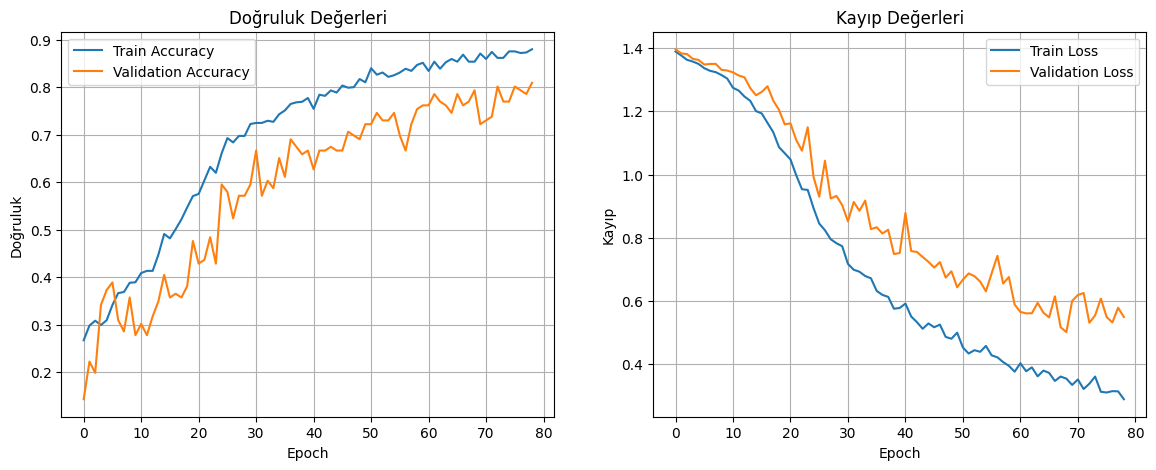

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Grafiği
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Doğruluk Değerleri')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.grid()

# Loss Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Kayıp Değerleri')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()
plt.grid()

plt.show()


In [ ]:
def preprocess_for_transfer_learning(mel_spec_db, target_size=(224, 224)):
    mel_spec_rescaled = mel_spec_db * 255.0
    mel_spec_rescaled = mel_spec_rescaled.astype(np.uint8)

    mel_tensor = tf.convert_to_tensor(mel_spec_rescaled, dtype=tf.uint8)
    mel_tensor = tf.expand_dims(mel_tensor, axis=-1)  # (64, 751, 1)
    mel_resized = tf.image.resize(mel_tensor, target_size)
    mel_rgb = tf.image.grayscale_to_rgb(mel_resized)  # (224, 224, 3)
    mel_rgb = tf.cast(mel_rgb, tf.float32) / 255.0

    return mel_rgb.numpy()


In [ ]:
def load_dataset_for_transfer(folder_path, normalize_method='minmax'):
    X = []
    y = []
    labels_set = set()

    for filename in os.listdir(folder_path):
        if filename.endswith(".wav"):
            label = extract_label_from_filename(filename)
            if label is None:
                continue
            labels_set.add(label)

    label2idx = {label: idx for idx, label in enumerate(sorted(labels_set))}
    print("Etiketler:", label2idx)

    for filename in os.listdir(folder_path):
        if not filename.endswith(".wav"):
            continue
        label = extract_label_from_filename(filename)
        if label is None:
            continue

        file_path = os.path.join(folder_path, filename)
        mel = extract_mel_spectrogram(file_path, normalize_method=normalize_method)
        if mel is not None:
            image = preprocess_for_transfer_learning(mel)
            X.append(image)
            y.append(label2idx[label])

    X = np.array(X)
    y = np.array(y)
    return X, y, label2idx


In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('en_iyisi.keras', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 112ms/step - accuracy: 0.2810 - loss: 1.3917 - val_accuracy: 0.4048 - val_loss: 1.3256 - learning_rate: 0.0010
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3182 - loss: 1.3711 - val_accuracy: 0.4167 - val_loss: 1.3404 - learning_rate: 0.0010
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.3413 - loss: 1.3255 - val_accuracy: 0.4524 - val_loss: 1.3100 - learning_rate: 0.0010
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3475 - loss: 1.3342 - val_accuracy: 0.2381 - val_loss: 1.3518 - learning_rate: 0.0010
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.3219 - loss: 1.3392 - val_accuracy: 0.3929 - val_loss: 1.3071 - learning_rate: 0.0010
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.3908 - loss: 1.3014 - val_accuracy: 0.3452 - val_loss: 1.3084 - learning_rate: 0.0010
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.3832 - loss: 1.3059 

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, Input

base_model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Dropout(0.3),

    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Dropout(0.3),
])

# Dondur
base_model.trainable = False

# Transfer Learning Model
model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

# Modeli derleme adımı eklendi
model.compile(optimizer=Adam(), # Optimizer olarak Adam kullandık, learning_rate default olabilir veya ayarlanabilir
              loss='sparse_categorical_crossentropy', # Etiketler integer olduğu için sparse_categorical_crossentropy
              metrics=['accuracy'])
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 14, 128)        │       168,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1792)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       459,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 628,996 (2.40 MB)

 Trainable params: 460,036 (1.75 MB)

 Non-trainable params: 168,960 (660.00 KB)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, InputLayer

num_classes = 4

model = Sequential([
    InputLayer(shape=(64, 751, 1)),

    Conv2D(32, kernel_size=(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(128, kernel_size=(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(256),
    BatchNormalization(),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 751, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 751, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 375, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 375, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 375, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 187, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 187, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 187, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 93, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 95232)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │    24,379,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,475,268 (93.37 MB)

 Trainable params: 24,474,308 (93.36 MB)

 Non-trainable params: 960 (3.75 KB)

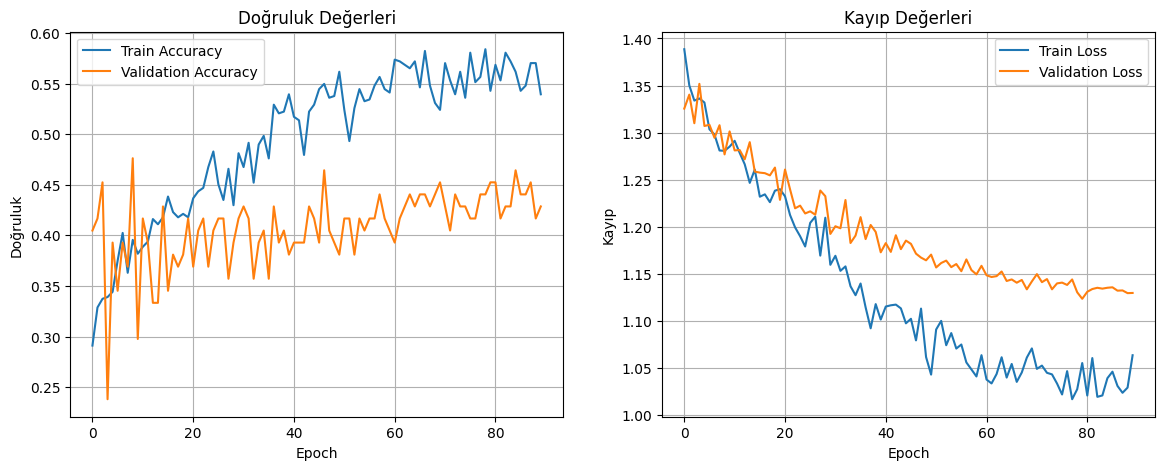

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Grafiği
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Doğruluk Değerleri')
plt.xlabel('Epoch')
plt.ylabel('Doğruluk')
plt.legend()
plt.grid()

# Loss Grafiği
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Kayıp Değerleri')
plt.xlabel('Epoch')
plt.ylabel('Kayıp')
plt.legend()
plt.grid()

plt.show()


In [ ]:
# Callback'ler
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint('en_iyi_model.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# Model eğitimi
history = model.fit(
    X_train, y_train_oh,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val_oh),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.3200 - loss: 2.5968
Epoch 1: val_loss improved from inf to 1.39340, saving model to en_iyi_model.keras
19/19 ━━━━━━━━━━━━━━━━━━━━ 116s 6s/step - accuracy: 0.3228 - loss: 2.5805 - val_accuracy: 0.3333 - val_loss: 1.3934 - learning_rate: 1.0000e-04
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.6127 - loss: 1.1139
Epoch 2: val_loss did not improve from 1.39340
19/19 ━━━━━━━━━━━━━━━━━━━━ 150s 6s/step - accuracy: 0.6125 - loss: 1.1139 - val_accuracy: 0.0952 - val_loss: 1.5863 - learning_rate: 1.0000e-04
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6662 - loss: 0.8354
Epoch 3: val_loss did not improve from 1.39340
19/19 ━━━━━━━━━━━━━━━━━━━━ 129s 6s/step - accuracy: 0.6675 - loss: 0.8344 - val_accuracy: 0.0952 - val_loss: 1.8513 - learning_rate: 1.0000e-04
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.7539 - loss: 0.6389
Epoch 4: val_loss did not improve from 1.39340
19/19 ━━

# Sliding Window uygulanmamış

In [ ]:
# bunu sliding window ile karşılaştırmak için sonradan deneyeceğim

max_len = 751  # Mel zaman adımı sabitliği için

def normalize_label(raw_label):
    raw_label = raw_label.lower().strip()
    if 'asthma' in raw_label:
        return 'asthma'
    elif 'bron' in raw_label:
        return 'bron'
    elif 'copd' in raw_label:
        return 'copd'
    elif 'heart failure' in raw_label:
        return 'heart failure'
    elif 'lung fibrosis' in raw_label:
        return 'lung fibrosis'
    elif 'pleural effusion' in raw_label or 'plueral effusion' in raw_label:
        return 'pleural effusion'
    elif 'pneumonia' in raw_label:
        return 'pneumonia'
    elif raw_label == 'n':
        return 'normal'
    else:
        print(f"Bilinmeyen sınıf: {raw_label}")
        return None

def extract_label_from_filename(file_name):
    try:
        raw_label = file_name.split('_')[1].split(',')[0].strip()
        return normalize_label(raw_label)
    except IndexError:
        print(f"Dosya adı formatı uygun değil: {file_name}")
        return None

def extract_mel_spectrogram(file_path, max_len=max_len):
    waveform, sample_rate = torchaudio.load(file_path)

    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=sample_rate,
        n_fft=400,
        hop_length=160,
        n_mels=64  # Daha iyi ayırt edici özellikler için
    )

    mel_spec = mel_transform(waveform).squeeze(0)  # (n_mels, time)

    # Logarithmic scale (daha iyi öğrenme performansı sağlar)
    mel_spec = torch.log(mel_spec + 1e-9)

    # Padding veya kesme
    if mel_spec.shape[1] < max_len:
        pad_amount = max_len - mel_spec.shape[1]
        mel_spec = torch.nn.functional.pad(mel_spec, (0, pad_amount))
    else:
        mel_spec = mel_spec[:, :max_len]

    return mel_spec.numpy()

def load_data_from_folder(folder_path, max_len=max_len):
    X = []
    y = []
    labels_set = set()

    for filename in os.listdir(folder_path):
        if filename.endswith('.wav'):
            label = extract_label_from_filename(filename)
            if label is not None:
                labels_set.add(label)

    label2idx = {label: idx for idx, label in enumerate(sorted(labels_set))}
    print(f"Bulunan sınıflar ve indeksleri: {label2idx}")

    for filename in os.listdir(folder_path):
        if filename.endswith('.wav'):
            label = extract_label_from_filename(filename)
            if label is None:
                continue
            file_path = os.path.join(folder_path, filename)
            mel_spec = extract_mel_spectrogram(file_path, max_len)
            X.append(mel_spec)
            y.append(label2idx[label])

    return np.array(X), np.array(y), label2idx

# Kullanım
train_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/train4"
val_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/val4"
test_folder = "/content/drive/My Drive/Colab Notebooks/akciger-ses-veriseti/test4"

X_train, y_train, label2idx = load_data_from_folder(train_folder)
X_val, y_val, _ = load_data_from_folder(val_folder)
X_test, y_test, _ = load_data_from_folder(test_folder)

# CNN için kanal boyutu ekle (N, 64, 751, 1)
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(f"Train data shape: {X_train.shape}, Train labels shape: {y_train.shape}")
print(f"Val data shape: {X_val.shape}, Val labels shape: {y_val.shape}")
print(f"Test data shape: {X_test.shape}, Test labels shape: {y_test.shape}")

Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}
Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}
Bulunan sınıflar ve indeksleri: {'asthma': 0, 'copd': 1, 'heart failure': 2, 'normal': 3}
Train data shape: (197, 64, 751, 1), Train labels shape: (197,)
Val data shape: (42, 64, 751, 1), Val labels shape: (42,)
Test data shape: (43, 64, 751, 1), Test labels shape: (43,)


In [ ]:
# X_train shape'i (N, 64, 751, 1) olduğu varsayılıyor
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)  # (N, 64*751*1)


In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_reshaped, y_train)

print(f"Before SMOTE: {Counter(y_train)}")
print(f"After SMOTE: {Counter(y_train_resampled)}")

# Modeliniz için tekrar orijinal 4D formata döndürün
X_train_resampled = X_train_resampled.reshape(-1, 64, 751, 1)


Before SMOTE: Counter({np.int64(3): 73, np.int64(0): 67, np.int64(2): 38, np.int64(1): 19})
After SMOTE: Counter({np.int64(2): 73, np.int64(0): 73, np.int64(1): 73, np.int64(3): 73})


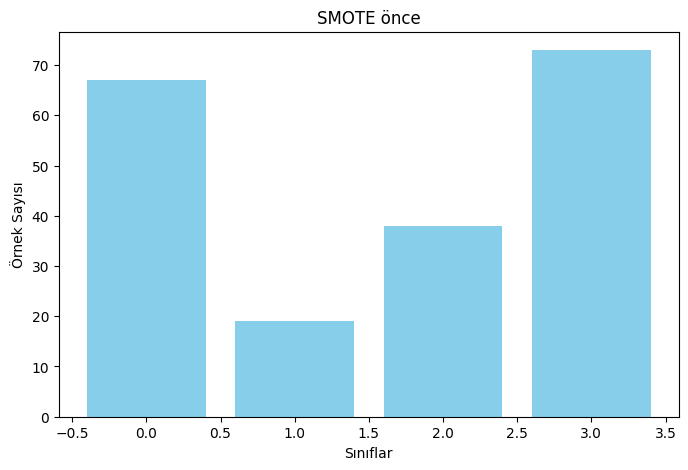

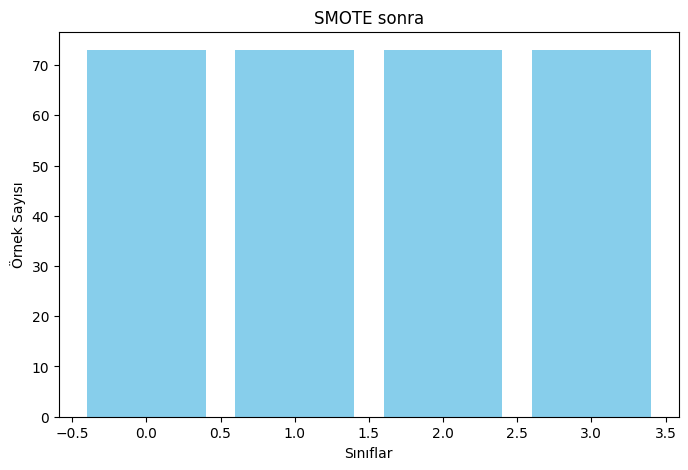

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

def plot_class_distribution(y, title="Sınıf Dağılımı"):
    counter = Counter(y)
    classes = list(counter.keys())
    counts = list(counter.values())
    plt.figure(figsize=(8,5))
    plt.bar(classes, counts, color='skyblue')
    plt.title(title)
    plt.xlabel("Sınıflar")
    plt.ylabel("Örnek Sayısı")
    plt.show()

# Kullanımı
plot_class_distribution(y_train, "SMOTE önce")
plot_class_distribution(y_train_resampled, "SMOTE sonra")


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

num_classes = len(label2idx)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(64, 751, 1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.3),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.4),

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

# Optimizasyon ve derleme
optimizer = Adam(learning_rate=1e-4)

model.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 64, 751, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 751, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 32, 375, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 375, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 375, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 375, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 187, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 187, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 187, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 187, 128)   │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 93, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 93, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,596 (432.02 KB)

 Trainable params: 110,148 (430.27 KB)

 Non-trainable params: 448 (1.75 KB)